# Customer Churn Prediction – Supervised Learning

## Business Objective

The company wants to find customers who may leave the service.

The goal of this project is to build a machine learning model that predicts whether a customer will **churn or not**.

## Target Variable

The target variable is **Churn**.

- **Yes** → Customer may leave
- **No** → Customer may stay

## Problem Type

This is a **Classification Problem** because the output has two categories: Yes and No.

## Dataset Features

### Numerical Features
- Age
- Annual Income
- Tenure
- Monthly Charges
- Support Calls
- Data Usage
- Satisfaction Score

### Categorical Features
- Contract Type
- Payment Method
- Region
- Plan Type

### Identifier
- Customer ID

`Customer_ID` is only used to identify customers, so it will **not be used for prediction**.

## Import and initial inspection

### Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, roc_auc_score)

### Load Dataset

In [2]:
# Load the customer churn dataset
df = pd.read_csv(r"C:\Calibo\Phase-2\ML\Business Use case\Supervised_Learning_Messy_Customer_Churn.csv")

### Sample records

In [3]:
# Display the first 5 rows
df.head()

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
0,CUST-1020,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,MONTHLY,Bank Transfer,North,Standard,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
2,CUST-1157,55.0,NaN,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic,Yes
3,CUST-1112,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,Yes
4,CUST-1149,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,Yes


### Check shape

In [4]:
# Check the number of rows and columns

df.shape

(184, 13)

### Check data types

In [5]:
# Check the data types of all columns

df.dtypes

Customer_ID               object
Age                      float64
Annual_Income             object
Tenure_Months            float64
Monthly_Charges          float64
Support_Calls_Last_3M    float64
Data_Usage_GB            float64
Satisfaction_Score       float64
Contract_Type             object
Payment_Method            object
Region                    object
Plan_Type                 object
Churn                     object
dtype: object

### Column Names

In [6]:
# Show only the column names

df.columns

Index(['Customer_ID', 'Age', 'Annual_Income', 'Tenure_Months',
       'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB',
       'Satisfaction_Score', 'Contract_Type', 'Payment_Method', 'Region',
       'Plan_Type', 'Churn'],
      dtype='object')

### Check dataset information

In [7]:
# Check columns, non-null values, and data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            184 non-null    object 
 1   Age                    176 non-null    float64
 2   Annual_Income          173 non-null    object 
 3   Tenure_Months          177 non-null    float64
 4   Monthly_Charges        178 non-null    float64
 5   Support_Calls_Last_3M  179 non-null    float64
 6   Data_Usage_GB          178 non-null    float64
 7   Satisfaction_Score     178 non-null    float64
 8   Contract_Type          184 non-null    object 
 9   Payment_Method         184 non-null    object 
 10  Region                 184 non-null    object 
 11  Plan_Type              184 non-null    object 
 12  Churn                  184 non-null    object 
dtypes: float64(6), object(7)
memory usage: 18.8+ KB


### Descriptive statistics

In [8]:
# Display descriptive statistics

df.describe(include='all')

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
count,184,176.000000,173,177.000000,178.000000,179.000000,178.000000,178.000000,184,184,184,184,184
unique,180,NaN,156,NaN,NaN,NaN,NaN,NaN,8,9,8,6,2
top,CUST-1043,NaN,76600.0,NaN,NaN,NaN,NaN,NaN,Monthly,Bank Transfer,South,Standard,Yes
freq,2,NaN,4,NaN,NaN,NaN,NaN,NaN,104,48,50,93,97
mean,NaN,36.164773,NaN,39.395480,80.205899,3.217877,17.806180,5.803371,NaN,NaN,NaN,NaN,NaN
std,NaN,12.865951,NaN,21.545185,74.179370,2.577455,9.245516,2.947869,NaN,NaN,NaN,NaN,NaN
min,NaN,-5.000000,NaN,1.000000,0.000000,0.000000,-10.000000,1.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,29.000000,NaN,25.000000,57.885000,2.000000,11.600000,4.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,36.000000,NaN,38.000000,73.565000,3.000000,18.200000,6.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,41.000000,NaN,55.000000,90.280000,4.000000,24.200000,8.000000,NaN,NaN,NaN,NaN,NaN


### Target distribution

In [9]:
# Check the distribution of the target variable

df['Churn'].value_counts()

Churn
Yes    97
No     87
Name: count, dtype: int64

### Target percentage

In [10]:
# Check the percentage distribution of Churn

df['Churn'].value_counts(normalize=True) * 100

Churn
Yes    52.717391
No     47.282609
Name: proportion, dtype: float64

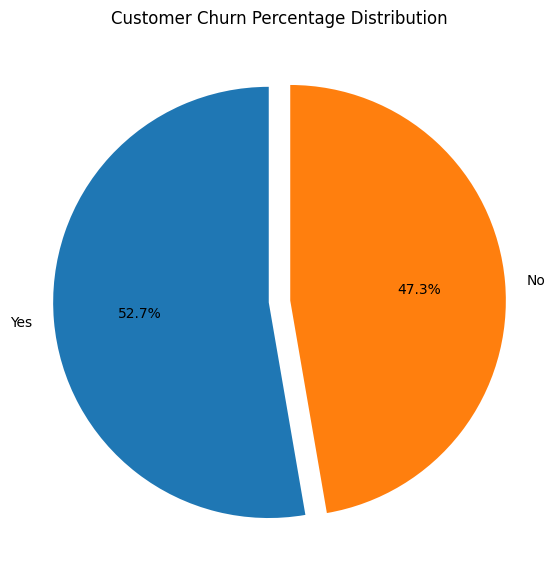

In [11]:
# Churn Percentage Distribution

churn_percentage = df['Churn'].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 7))

plt.pie(
    churn_percentage,
    labels=churn_percentage.index,
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.05, 0.05]
)

plt.title("Customer Churn Percentage Distribution")

plt.show()

### Missing values

In [12]:
# Check missing values in each column

df.isna().sum()

Customer_ID               0
Age                       8
Annual_Income            11
Tenure_Months             7
Monthly_Charges           6
Support_Calls_Last_3M     5
Data_Usage_GB             6
Satisfaction_Score        6
Contract_Type             0
Payment_Method            0
Region                    0
Plan_Type                 0
Churn                     0
dtype: int64

### Duplicate records

In [13]:
# Check the number of duplicate records

df.duplicated().sum()

np.int64(4)

### Unique values

In [14]:
# Check unique values in each categorical column

for column in df.select_dtypes(include='object').columns:
    display(pd.DataFrame({
        'Column': [column],
        'Unique_Values': [df[column].unique()]
    }))

,Column,Unique_Values
0,Customer_ID,"[CUST-1020, CUST-1043, CUST-1157, CUST-1112, C..."


,Column,Unique_Values
0,Annual_Income,"[23800.0, 69400.0, nan, 80000.0, 95700.0, 8800..."


,Column,Unique_Values
0,Contract_Type,"[MONTHLY, Monthly, 1 Year, 2 Year, 2-Year, 1 y..."


,Column,Unique_Values
0,Payment_Method,"[Bank Transfer, UPI, Debit Card, Credit Card, ..."


,Column,Unique_Values
0,Region,"[North, South, West, East, west, NORTH, ?, sou..."


,Column,Unique_Values
0,Plan_Type,"[Standard, Basic, Premium, basic, premium, STA..."


,Column,Unique_Values
0,Churn,"[Yes, No]"


In [15]:
# Value count for selected columns

df['Annual_Income'].value_counts(dropna=False)

Annual_Income
NaN         11
76600.0      4
69400.0      2
59300.0      2
100000.0     2
            ..
54100.0      1
63000.0      1
45300.0      1
47100.0      1
48300.0      1
Name: count, Length: 157, dtype: int64

In [16]:
# Contract Type value count

df['Contract_Type'].value_counts(dropna=False)

Contract_Type
Monthly    104
1 Year      52
2 Year      23
MONTHLY      1
2-Year       1
1 year       1
monthly      1
?            1
Name: count, dtype: int64

In [17]:
# Payment Method value count

df['Payment_Method'].value_counts(dropna=False)

Payment_Method
Bank Transfer    48
UPI              46
Credit Card      43
Debit Card       42
?                 1
bank transfer     1
upi               1
Unknown           1
Credit card       1
Name: count, dtype: int64

In [18]:
# Region value count

df['Region'].value_counts(dropna=False)

Region
South     50
North     49
West      47
East      34
west       1
NORTH      1
?          1
south      1
Name: count, dtype: int64

In [19]:
# Plan Type value count

df['Plan_Type'].value_counts(dropna=False)

Plan_Type
Standard     93
Basic        48
Premium      40
basic         1
premium       1
STANDARD      1
Name: count, dtype: int64

In [20]:
# Churn value count

df['Churn'].value_counts(dropna=False)

Churn
Yes    97
No     87
Name: count, dtype: int64

### Numerical ranges

In [21]:
# Check minimum and maximum values of numerical columns

df.select_dtypes(include='number').agg(['min', 'max']).T

,min,max
Age,-5.0,145.0
Tenure_Months,1.0,150.0
Monthly_Charges,0.0,999.0
Support_Calls_Last_3M,0.0,30.0
Data_Usage_GB,-10.0,44.0
Satisfaction_Score,1.0,15.0


### Negative values

In [22]:
# Check negative values in numerical columns

(df.select_dtypes(include='number') < 0).sum()

Age                      1
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            7
Satisfaction_Score       0
dtype: int64

### Check suspicious placeholder values

In [23]:
# Check for common placeholder values

placeholder_values = ['N/A', 'NA', '?']

{
    value: (df == value).sum().sum()
    for value in placeholder_values
}

{'N/A': np.int64(0), 'NA': np.int64(0), '?': np.int64(4)}

### Check categorical values

In [24]:
# Check for inconsistent categorical labels

categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    display(df[column].value_counts(dropna=False))

Customer_ID
CUST-1043    2
CUST-1110    2
CUST-1008    2
CUST-1152    2
CUST-1149    1
            ..
CUST-1107    1
CUST-1015    1
CUST-1093    1
CUST-1180    1
CUST-1103    1
Name: count, Length: 180, dtype: int64

Annual_Income
NaN         11
76600.0      4
69400.0      2
59300.0      2
100000.0     2
            ..
54100.0      1
63000.0      1
45300.0      1
47100.0      1
48300.0      1
Name: count, Length: 157, dtype: int64

Contract_Type
Monthly    104
1 Year      52
2 Year      23
MONTHLY      1
2-Year       1
1 year       1
monthly      1
?            1
Name: count, dtype: int64

Payment_Method
Bank Transfer    48
UPI              46
Credit Card      43
Debit Card       42
?                 1
bank transfer     1
upi               1
Unknown           1
Credit card       1
Name: count, dtype: int64

Region
South     50
North     49
West      47
East      34
west       1
NORTH      1
?          1
south      1
Name: count, dtype: int64

Plan_Type
Standard     93
Basic        48
Premium      40
basic         1
premium       1
STANDARD      1
Name: count, dtype: int64

Churn
Yes    97
No     87
Name: count, dtype: int64

## Data cleaning

In [25]:
# Check missing values

df.isna().sum()

Customer_ID               0
Age                       8
Annual_Income            11
Tenure_Months             7
Monthly_Charges           6
Support_Calls_Last_3M     5
Data_Usage_GB             6
Satisfaction_Score        6
Contract_Type             0
Payment_Method            0
Region                    0
Plan_Type                 0
Churn                     0
dtype: int64

In [26]:
# Check duplicate records

df.duplicated().sum()

np.int64(4)

In [27]:
# View duplicate records

df[df.duplicated(keep=False)]

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
46,CUST-1110,35.0,29800.0,72.0,115.28,2.0,18.9,5.0,1 Year,Bank Transfer,West,Premium,Yes
71,CUST-1110,35.0,29800.0,72.0,115.28,2.0,18.9,5.0,1 Year,Bank Transfer,West,Premium,Yes
119,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
132,CUST-1008,44.0,43400.0,60.0,95.26,2.0,26.9,1.0,Monthly,Debit Card,South,Basic,Yes
154,CUST-1008,44.0,43400.0,60.0,95.26,2.0,26.9,1.0,Monthly,Debit Card,South,Basic,Yes
169,CUST-1152,39.0,76600.0,25.0,90.28,4.0,8.4,8.0,Monthly,Bank Transfer,West,Premium,No
176,CUST-1152,39.0,76600.0,25.0,90.28,4.0,8.4,8.0,Monthly,Bank Transfer,West,Premium,No


In [28]:
# Check placeholder values

placeholder_values = ['N/A', 'NA', '?']

{
    value: (df == value).sum().sum()
    for value in placeholder_values
}

{'N/A': np.int64(0), 'NA': np.int64(0), '?': np.int64(4)}

In [29]:
# Find rows containing placeholder values

for value in placeholder_values:
    display(df[df.eq(value).any(axis=1)])

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn


,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn


,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
105,CUST-1078,33.0,89900.0,15.0,59.47,NaN,25.3,10.0,Monthly,?,South,Standard,No
114,CUST-1034,25.0,?,39.0,140.55,2.0,6.5,5.0,Monthly,Credit Card,West,Standard,No
146,CUST-1161,26.0,20400.0,26.0,82.77,2.0,13.2,9.0,Monthly,Bank Transfer,?,Basic,Yes
155,CUST-1059,NaN,58000.0,33.0,71.78,2.0,NaN,8.0,?,Bank Transfer,South,Standard,No


In [30]:
# Check numerical columns

df.select_dtypes(include='number').describe().T

,count,mean,std,min,25%,50%,75%,max
Age,176.0,36.164773,12.865951,-5.0,29.000,36.000,41.00,145.0
Tenure_Months,177.0,39.395480,21.545185,1.0,25.000,38.000,55.00,150.0
Monthly_Charges,178.0,80.205899,74.179370,0.0,57.885,73.565,90.28,999.0
Support_Calls_Last_3M,179.0,3.217877,2.577455,0.0,2.000,3.000,4.00,30.0
Data_Usage_GB,178.0,17.806180,9.245516,-10.0,11.600,18.200,24.20,44.0
Satisfaction_Score,178.0,5.803371,2.947869,1.0,4.000,6.000,8.00,15.0


In [31]:
# Check negative numerical values

(df.select_dtypes(include='number') < 0).sum()

Age                      1
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            7
Satisfaction_Score       0
dtype: int64

In [32]:
# Check unrealistic age values

df[(df['Age'] < 18) | (df['Age'] > 100)]

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
100,CUST-1080,16.0,NaN,8.0,84.70,1.0,30.5,5.0,Monthly,Credit Card,West,Basic,Yes
127,CUST-1004,145.0,55500.0,35.0,120.65,2.0,14.3,6.0,1 Year,Credit Card,East,Premium,No
133,CUST-1111,17.0,31700.0,31.0,62.54,3.0,30.1,10.0,Monthly,Credit Card,South,Standard,No
140,CUST-1014,17.0,61000.0,40.0,75.05,3.0,17.8,8.0,Monthly,Bank Transfer,West,Standard,No
144,CUST-1018,-5.0,75900.0,64.0,137.15,5.0,14.2,5.0,Monthly,UPI,North,Premium,Yes
162,CUST-1038,16.0,62300.0,38.0,39.90,4.0,24.8,3.0,Monthly,Credit card,East,Basic,Yes
174,CUST-1075,10.0,79200.0,47.0,60.09,2.0,19.7,1.0,Monthly,UPI,South,Standard,No


In [33]:
# Check negative income
# Annual_Income is currently stored as object, so first inspect its values

df['Annual_Income'].unique()

array(['23800.0', '69400.0', nan, '80000.0', '95700.0', '88000.0',
       '49100.0', '69200.0', '43300.0', '59800.0', '59200.0', '23700.0',
       '75700.0', '70900.0', '66100.0', '91000.0', '46500.0', '8600.0',
       '88300.0', '106900.0', '90400.0', '52600.0', '51200.0', '46900.0',
       '49700.0', '69100.0', '101900.0', '77900.0', '79300.0', '76800.0',
       '66700.0', '55200.0', '94800.0', '42600.0', '83900.0', '19600.0',
       '57300.0', '83300.0', '76600.0', '64700.0', '48700.0', '120900.0',
       '35800.0', '29800.0', '60600.0', '45700.0', '83500.0', '55000.0',
       '67400.0', '78200.0', '104900.0', '73300.0', '70300.0', '90300.0',
       '31300.0', '70500.0', '116500.0', '68300.0', '53100.0', '73600.0',
       '72500.0', '56900.0', '50800.0', '95200.0', '82200.0', '64100.0',
       '99200.0', '73000.0', '98600.0', '92100.0', '57800.0', '38400.0',
       '59100.0', '100000.0', '96200.0', '107900.0', '95800.0',
       '100100.0', '53000.0', '44400.0', '52400.0', '69600.0',

In [34]:
# Check negative usage

df[df['Data_Usage_GB'] < 0]

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
6,CUST-1025,31.0,88000.0,37.0,88.42,4.0,-2.1,9.0,1 Year,Debit Card,South,Standard,No
45,CUST-1105,34.0,35800.0,60.0,118.63,3.0,-0.8,7.0,2 Year,UPI,East,Standard,No
63,CUST-1079,NaN,53100.0,29.0,83.71,3.0,-1.6,5.0,Monthly,UPI,North,Basic,Yes
77,CUST-1033,36.0,57800.0,72.0,50.61,3.0,-1.1,1.0,Monthly,Credit Card,North,Standard,Yes
120,CUST-1124,22.0,50100.0,57.0,93.56,3.0,-0.3,9.0,Monthly,UPI,South,Standard,No
177,CUST-1021,51.0,100400.0,14.0,51.52,2.0,-2.0,1.0,2 Year,UPI,South,Premium,No
178,CUST-1072,51.0,NaN,38.0,77.19,5.0,-10.0,5.0,Monthly,Credit Card,West,Standard,No


In [35]:
# Check negative monthly charges

df[df['Monthly_Charges'] < 0].sum()

Customer_ID                0
Age                      0.0
Annual_Income              0
Tenure_Months            0.0
Monthly_Charges          0.0
Support_Calls_Last_3M    0.0
Data_Usage_GB            0.0
Satisfaction_Score       0.0
Contract_Type              0
Payment_Method             0
Region                     0
Plan_Type                  0
Churn                      0
dtype: object

In [36]:
# Check negative tenure

df[df['Tenure_Months'] < 0].sum()

Customer_ID                0
Age                      0.0
Annual_Income              0
Tenure_Months            0.0
Monthly_Charges          0.0
Support_Calls_Last_3M    0.0
Data_Usage_GB            0.0
Satisfaction_Score       0.0
Contract_Type              0
Payment_Method             0
Region                     0
Plan_Type                  0
Churn                      0
dtype: object

In [37]:
# Check negative support calls

df[df['Support_Calls_Last_3M'] < 0].sum()

Customer_ID                0
Age                      0.0
Annual_Income              0
Tenure_Months            0.0
Monthly_Charges          0.0
Support_Calls_Last_3M    0.0
Data_Usage_GB            0.0
Satisfaction_Score       0.0
Contract_Type              0
Payment_Method             0
Region                     0
Plan_Type                  0
Churn                      0
dtype: object

In [38]:
# Check satisfaction score range

df[(df['Satisfaction_Score'] < 1) | (df['Satisfaction_Score'] > 5)]

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
3,CUST-1112,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,Yes
4,CUST-1149,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,Yes
5,CUST-1016,30.0,NaN,22.0,74.89,3.0,5.6,10.0,1 Year,Bank Transfer,West,Standard,No
6,CUST-1025,31.0,88000.0,37.0,88.42,4.0,-2.1,9.0,1 Year,Debit Card,South,Standard,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,CUST-1122,27.0,64700.0,36.0,68.19,4.0,26.6,7.0,Monthly,UPI,North,Premium,No
176,CUST-1152,39.0,76600.0,25.0,90.28,4.0,8.4,8.0,Monthly,Bank Transfer,West,Premium,No
179,CUST-1107,55.0,54100.0,68.0,99.59,6.0,21.5,8.0,1 Year,Bank Transfer,East,Basic,Yes
180,CUST-1015,19.0,63000.0,NaN,64.24,1.0,13.0,7.0,Monthly,Credit Card,south,Premium,Yes


In [39]:
# Check inconsistent categorical values
# Removes extra spaces and shows the cleaned 

categorical_columns = [
    'Contract_Type',
    'Payment_Method',
    'Region',
    'Plan_Type',
    'Churn'
]

for column in categorical_columns:
    display(df[column].astype(str).str.strip().unique())

array(['MONTHLY', 'Monthly', '1 Year', '2 Year', '2-Year', '1 year',
       'monthly', '?'], dtype=object)

array(['Bank Transfer', 'UPI', 'Debit Card', 'Credit Card', '?',
       'bank transfer', 'upi', 'Unknown', 'Credit card'], dtype=object)

array(['North', 'South', 'West', 'East', 'west', 'NORTH', '?', 'south'],
      dtype=object)

array(['Standard', 'Basic', 'Premium', 'basic', 'premium', 'STANDARD'],
      dtype=object)

array(['Yes', 'No'], dtype=object)

In [40]:
# Check outliers using IQR

numerical_columns = [
    'Age',
    'Tenure_Months',
    'Monthly_Charges',
    'Support_Calls_Last_3M',
    'Data_Usage_GB',
    'Satisfaction_Score'
]

Q1 = df[numerical_columns].quantile(0.25)
Q3 = df[numerical_columns].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = (
    (df[numerical_columns] < lower_limit) |
    (df[numerical_columns] > upper_limit)
)

outliers.sum()

Age                      5
Tenure_Months            1
Monthly_Charges          4
Support_Calls_Last_3M    1
Data_Usage_GB            2
Satisfaction_Score       1
dtype: int64

In [41]:
# View rows containing outliers

df[outliers.any(axis=1)]

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
29,CUST-1114,61.0,79300.0,29.0,65.28,3.0,21.3,5.0,2 Year,Bank Transfer,East,Standard,No
35,CUST-1030,33.0,83900.0,42.0,80.50,30.0,19.0,3.0,2 Year,Credit Card,North,Standard,Yes
40,CUST-1013,38.0,76600.0,150.0,64.92,3.0,20.8,9.0,1 Year,UPI,East,Standard,No
55,CUST-1173,35.0,73300.0,51.0,134.89,2.0,44.0,6.0,Monthly,UPI,North,Basic,Yes
90,CUST-1045,21.0,33300.0,53.0,0.00,3.0,29.8,5.0,Monthly,Credit Card,East,Premium,No
114,CUST-1034,25.0,?,39.0,140.55,2.0,6.5,5.0,Monthly,Credit Card,West,Standard,No
127,CUST-1004,145.0,55500.0,35.0,120.65,2.0,14.3,6.0,1 Year,Credit Card,East,Premium,No
144,CUST-1018,-5.0,75900.0,64.0,137.15,5.0,14.2,5.0,Monthly,UPI,North,Premium,Yes
157,CUST-1089,31.0,54600.0,36.0,999.00,4.0,NaN,10.0,1 Year,Credit Card,West,Standard,Yes
166,CUST-1053,29.0,53900.0,51.0,55.06,2.0,24.5,15.0,1 Year,Bank Transfer,South,Basic,Yes


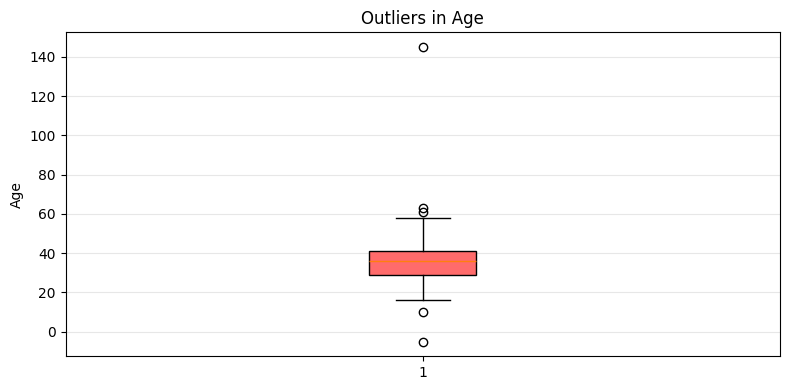

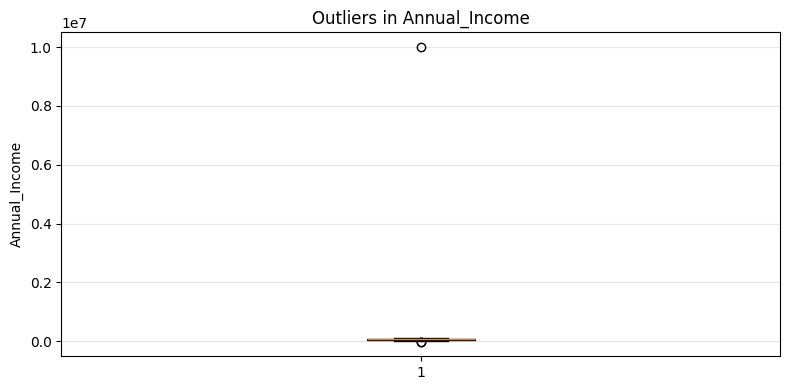

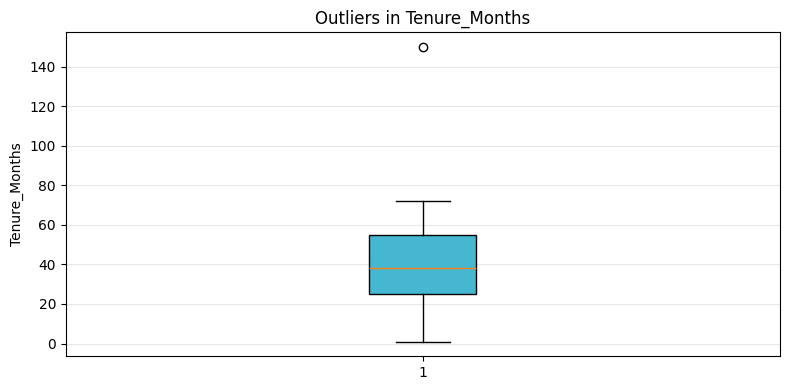

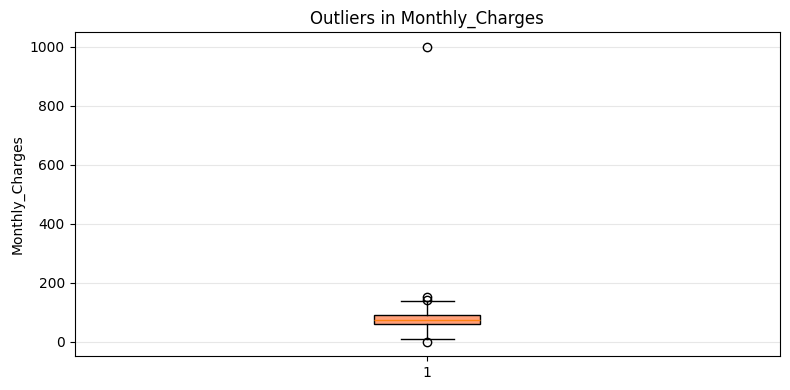

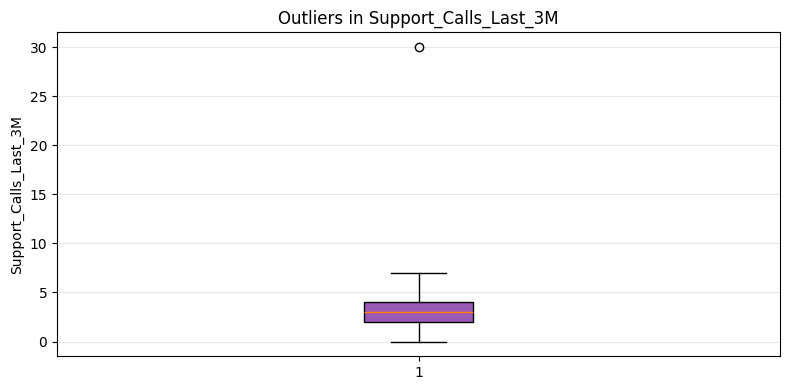

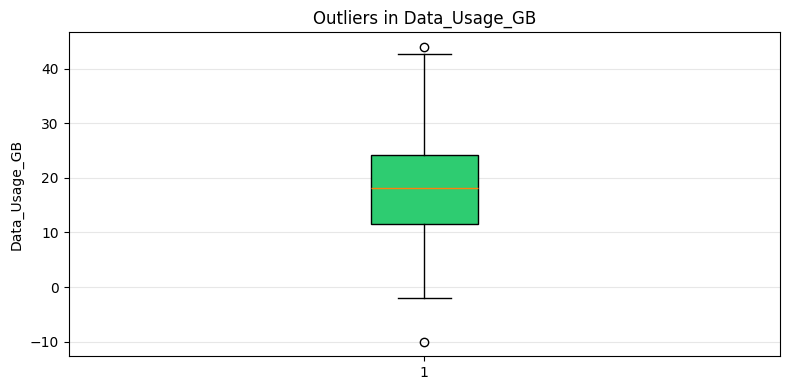

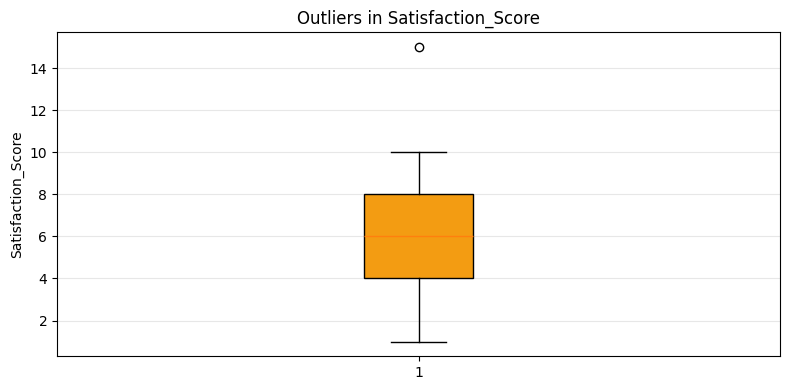

In [42]:
# Convert Annual_Income to numeric

df['Annual_Income'] = pd.to_numeric(
    df['Annual_Income'],
    errors='coerce'
)

# Numerical columns for outlier analysis

numerical_columns = [
    'Age',
    'Annual_Income',
    'Tenure_Months',
    'Monthly_Charges',
    'Support_Calls_Last_3M',
    'Data_Usage_GB',
    'Satisfaction_Score'
]
# outlier graphs

colors = [
    '#FF6B6B',
    '#4ECDC4',
    '#45B7D1',
    '#FFA07A',
    '#9B59B6',
    '#2ECC71',
    '#F39C12'
]

for column, color in zip(numerical_columns, colors):

    plt.figure(figsize=(8, 4))

    box = plt.boxplot(
        df[column].dropna().astype(float),
        patch_artist=True
    )

    box['boxes'][0].set_facecolor(color)

    plt.title(f'Outliers in {column}')
    plt.ylabel(column)
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

In [43]:
# Check whitespace in categorical columns

for column in categorical_columns:
    display(
        df[column][
            df[column].astype(str) != df[column].astype(str).str.strip()
        ]
    )

Series([], Name: Contract_Type, dtype: object)

Series([], Name: Payment_Method, dtype: object)

180    south 
Name: Region, dtype: object

150    STANDARD 
Name: Plan_Type, dtype: object

Series([], Name: Churn, dtype: object)

In [44]:
# Clean extra spaces and capitalization

for column in categorical_columns:
    df[column] = df[column].astype(str).str.strip().str.title()

df[categorical_columns].head()

,Contract_Type,Payment_Method,Region,Plan_Type,Churn
0,Monthly,Bank Transfer,North,Standard,Yes
1,Monthly,Bank Transfer,South,Basic,Yes
2,Monthly,Upi,West,Basic,Yes
3,Monthly,Upi,South,Standard,Yes
4,Monthly,Debit Card,West,Premium,Yes


In [45]:
# Convert placeholder values to missing values

df = df.replace(['N/A', 'NA', '?'], np.nan)

df.isna().sum()

Customer_ID               0
Age                       8
Annual_Income            12
Tenure_Months             7
Monthly_Charges           6
Support_Calls_Last_3M     5
Data_Usage_GB             6
Satisfaction_Score        6
Contract_Type             1
Payment_Method            1
Region                    1
Plan_Type                 0
Churn                     0
dtype: int64

In [46]:
# Check duplicates again before deciding whether to remove them

df.duplicated().sum()

np.int64(4)

In [47]:
# Remove exact duplicate records
# Decision: exact duplicate rows do not provide additional information,
# so they can be removed.

df = df.drop_duplicates()

df.shape

(180, 13)

In [48]:
# Final missing-value check after cleaning placeholders

df.isna().sum()

Customer_ID               0
Age                       8
Annual_Income            12
Tenure_Months             7
Monthly_Charges           6
Support_Calls_Last_3M     5
Data_Usage_GB             6
Satisfaction_Score        6
Contract_Type             1
Payment_Method            1
Region                    1
Plan_Type                 0
Churn                     0
dtype: int64

In [49]:
# Handle missing values in numerical columns
# Fill numerical missing values with the median

numerical_columns = df.select_dtypes(include='number').columns

for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

df[numerical_columns].isna().sum()

Age                      0
Annual_Income            0
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
dtype: int64

In [50]:
# Handle Annual_Income
# Annual_Income is stored as object, so convert it to numeric

df['Annual_Income'] = pd.to_numeric(df['Annual_Income'], errors='coerce')

df['Annual_Income'] = df['Annual_Income'].fillna(
    df['Annual_Income'].median()
)

df['Annual_Income'].isna().sum()

np.int64(0)

In [51]:
# Handle missing values in categorical columns
# Fill categorical missing values with the most frequent value

categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

df[categorical_columns].isna().sum()

Customer_ID       0
Contract_Type     0
Payment_Method    0
Region            0
Plan_Type         0
Churn             0
dtype: int64

In [52]:
# Check all missing values after handling

df.isna().sum()

Customer_ID              0
Age                      0
Annual_Income            0
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
Contract_Type            0
Payment_Method           0
Region                   0
Plan_Type                0
Churn                    0
dtype: int64

In [53]:
# Save the cleaned dataset as a CSV file

df.to_csv("Cleaned_Customer_Churn.csv", index=False)

### Data Cleaning Decisions

1.Missing values were handled using median for numerical columns and mode for categorical columns.

2.Placeholder values such as N/A, NA, and ? were treated as missing values.

3.Exact duplicate records were removed.

4.Outliers and unusual values were identified and investigated, not blindly deleted.

5.Categorical values were standardized for consistent spelling, capitalization, and spacing.

## Exploratory Data Analysis (EDA)

#### Churn by Contract Type

In [54]:
# Churn percentage by contract type

contract_churn = pd.crosstab(
    df['Contract_Type'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn

Churn,No,Yes
Contract_Type,,
1 Year,53.846154,46.153846
2 Year,82.608696,17.391304
2-Year,0.000000,100.000000
Monthly,37.500000,62.500000


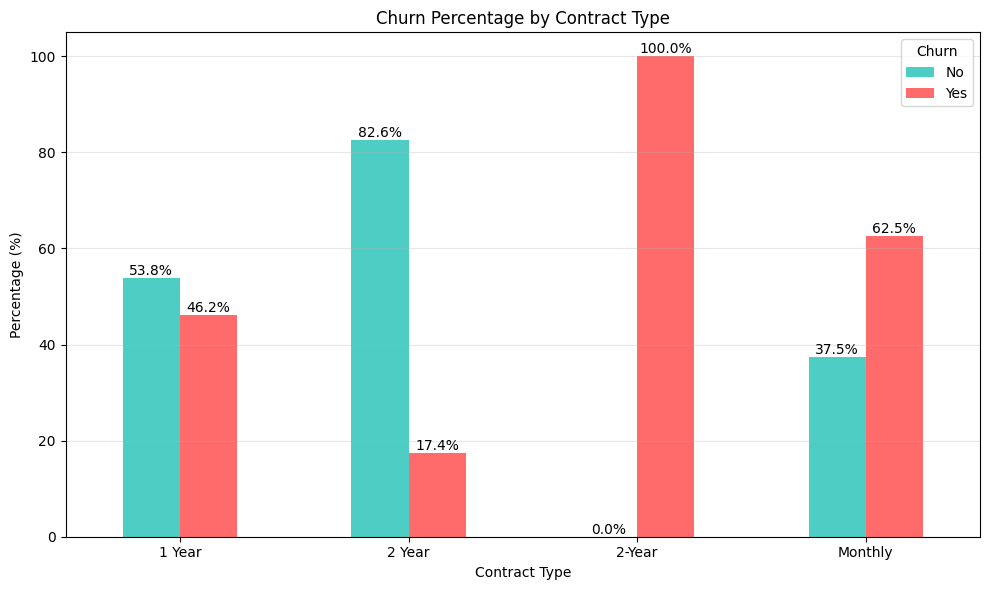

In [55]:
# bar graph - Churn by Contract Type

ax = contract_churn.plot(
    kind='bar',
    figsize=(10, 6),
    color=['#4ECDC4', '#FF6B6B']
)

plt.title('Churn Percentage by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.grid(axis='y', alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

### Business Meaning

The chart shows how churn differs across contract types. Contract categories with a higher percentage of **Churn = Yes** may require more attention from the retention team.

#### Churn and Customer Satisfaction

In [56]:
# Churn percentage by satisfaction score

satisfaction_churn = pd.crosstab(
    df['Satisfaction_Score'],
    df['Churn'],
    normalize='index'
) * 100

satisfaction_churn

Churn,No,Yes
Satisfaction_Score,,
1.0,31.578947,68.421053
2.0,54.545455,45.454545
3.0,30.769231,69.230769
4.0,44.444444,55.555556
5.0,33.333333,66.666667
6.0,50.000000,50.000000
7.0,56.250000,43.750000
8.0,50.000000,50.000000
9.0,56.521739,43.478261


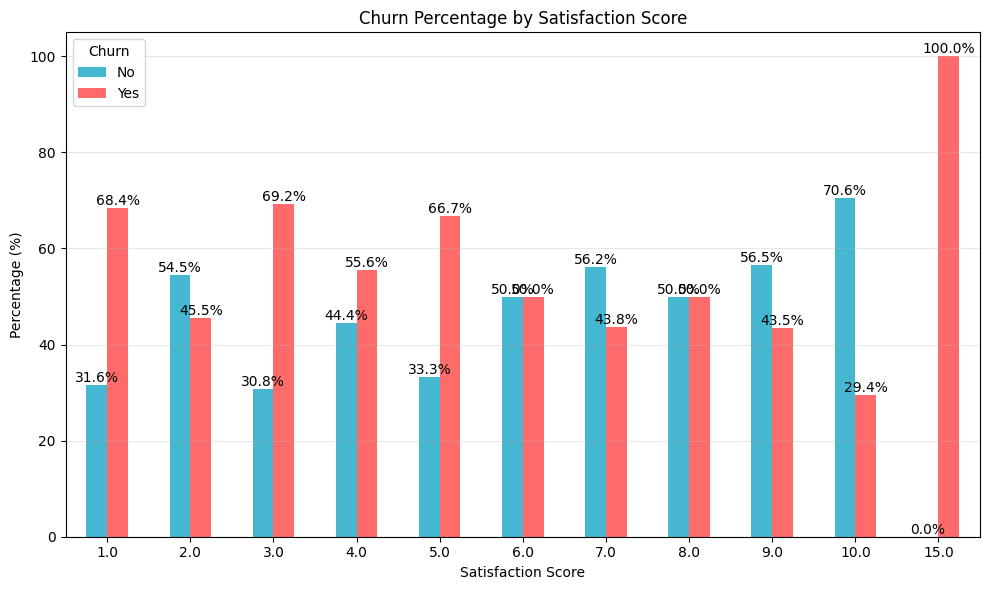

In [57]:
# Satisfaction Score vs Churn

ax = satisfaction_churn.plot(
    kind='bar',
    figsize=(10, 6),
    color=['#45B7D1', '#FF6B6B']
)

plt.title('Churn Percentage by Satisfaction Score')
plt.xlabel('Satisfaction Score')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.grid(axis='y', alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

### Business Meaning

This visualization helps identify whether lower satisfaction scores are associated with higher churn. If lower satisfaction groups show more churn, improving customer experience may be important for retention.

#### Tenure and Churn

<Figure size 900x600 with 0 Axes>

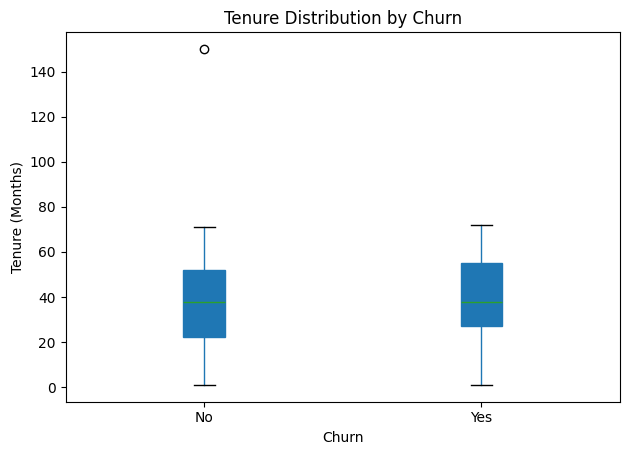

In [58]:
# Tenure distribution by churn

plt.figure(figsize=(9, 6))

df.boxplot(
    column='Tenure_Months',
    by='Churn',
    grid=False,
    patch_artist=True
)

plt.title('Tenure Distribution by Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')

plt.tight_layout()
plt.show()

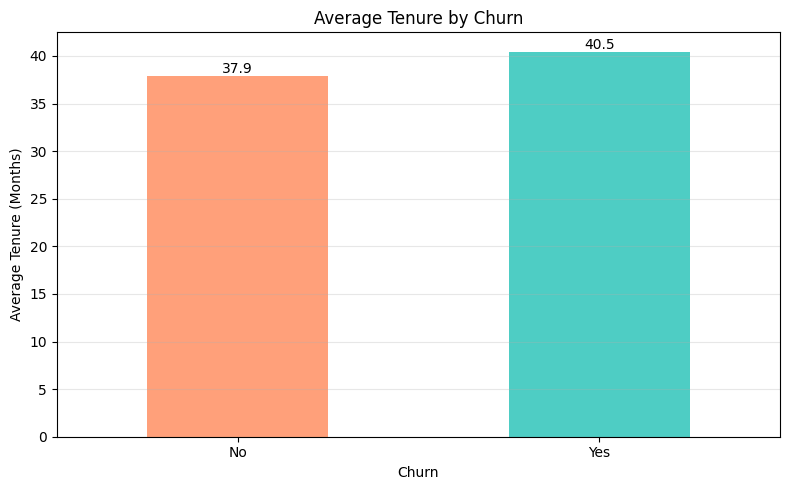

In [59]:
# Average tenure by churn

tenure_churn = df.groupby('Churn')['Tenure_Months'].mean()

ax = tenure_churn.plot(
    kind='bar',
    figsize=(8, 5),
    color=['#FFA07A', '#4ECDC4']
)

plt.title('Average Tenure by Churn')
plt.xlabel('Churn')
plt.ylabel('Average Tenure (Months)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.tight_layout()
plt.show()

### Business Meaning

The tenure comparison shows whether newer or longer-term customers appear more likely to churn. Customers with shorter tenure may require stronger onboarding and early-stage retention support if the data shows higher churn among them.

#### Monthly Charges and Churn

<Figure size 900x600 with 0 Axes>

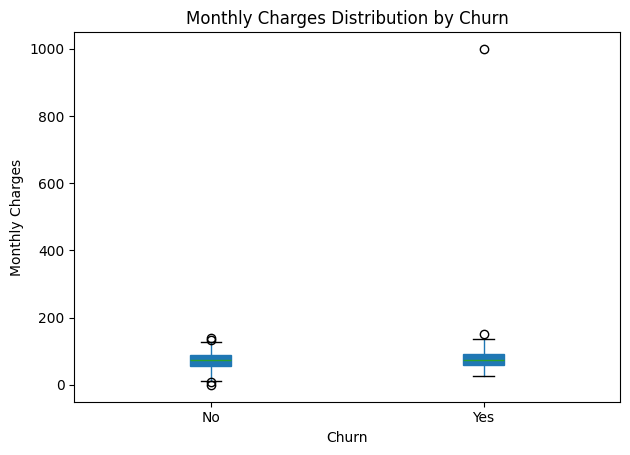

In [60]:
# Monthly charges distribution by churn

plt.figure(figsize=(9, 6))

df.boxplot(
    column='Monthly_Charges',
    by='Churn',
    grid=False,
    patch_artist=True
)

plt.title('Monthly Charges Distribution by Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.tight_layout()
plt.show()

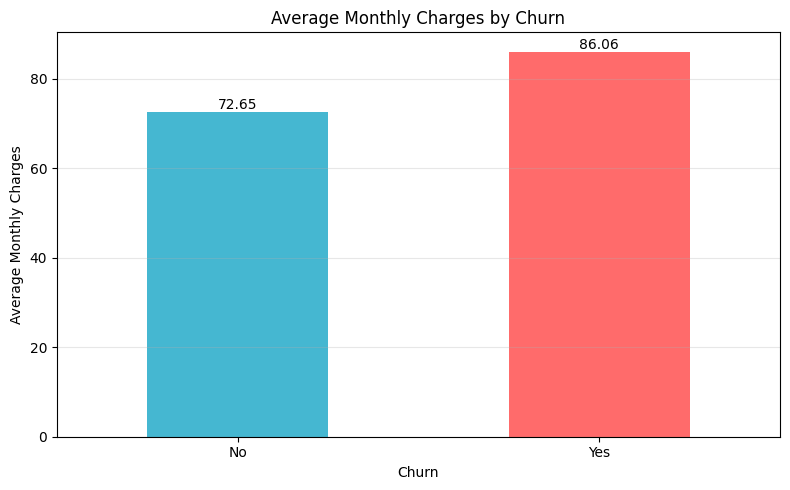

In [61]:
# Average monthly charges by churn

monthly_charge_churn = df.groupby('Churn')['Monthly_Charges'].mean()

ax = monthly_charge_churn.plot(
    kind='bar',
    figsize=(8, 5),
    color=['#45B7D1', '#FF6B6B']
)

plt.title('Average Monthly Charges by Churn')
plt.xlabel('Churn')
plt.ylabel('Average Monthly Charges')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

### Business Meaning

The comparison helps identify whether customers paying higher or lower monthly charges show different churn patterns. If churned customers have noticeably different charges, pricing or plan structure may be worth investigating.

#### Customer Characteristics Associated with Churn

In [62]:
# Average customer characteristics by churn

customer_characteristics = df.groupby('Churn')[
    [
        'Age',
        'Annual_Income',
        'Tenure_Months',
        'Monthly_Charges',
        'Support_Calls_Last_3M',
        'Data_Usage_GB',
        'Satisfaction_Score'
    ]
].mean()

customer_characteristics

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
Churn,,,,,,,
No,36.325581,178836.034884,37.930233,72.651860,2.953488,15.832558,6.302326
Yes,35.914894,65242.553191,40.457447,86.061809,3.436170,19.631915,5.361702


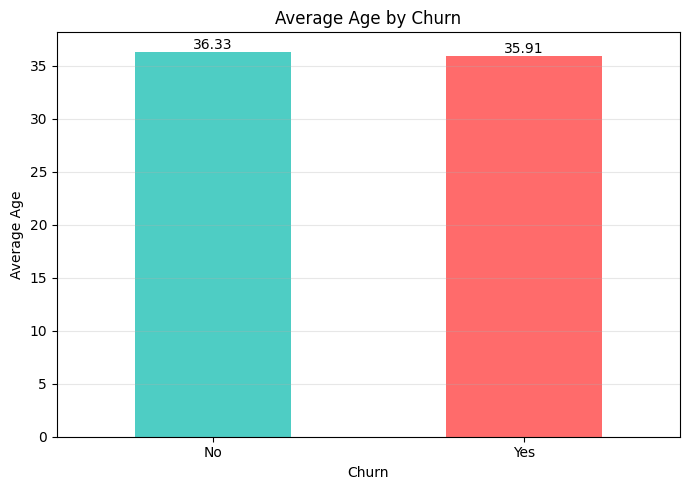

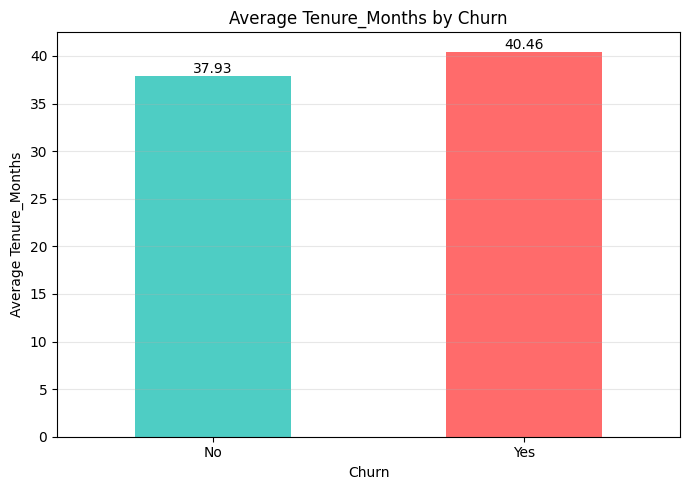

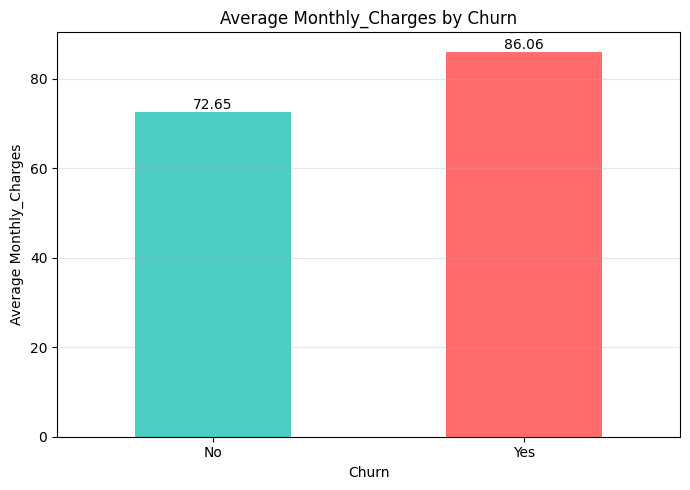

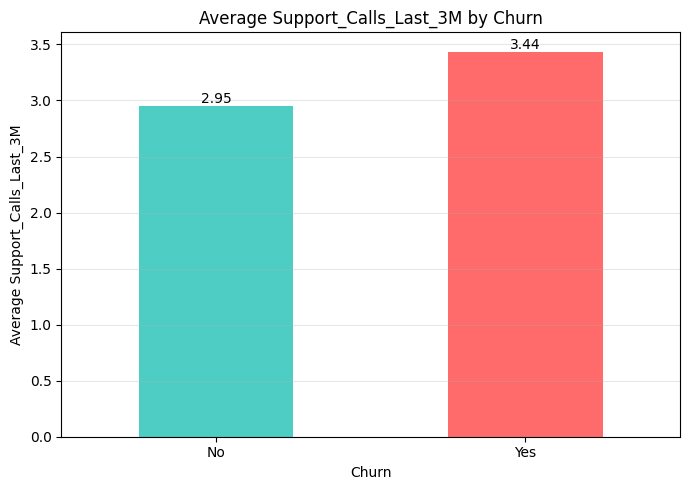

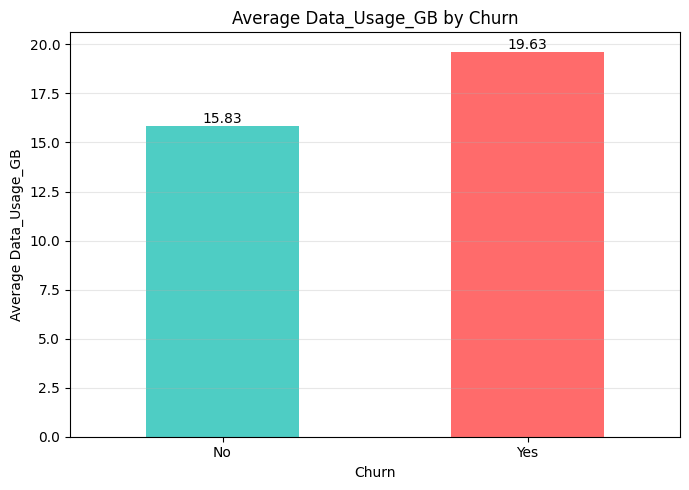

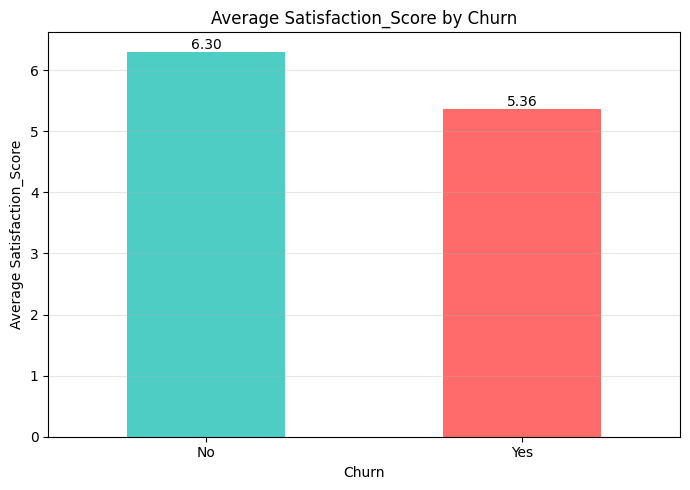

In [63]:
# Average customer characteristics

characteristics = [
    'Age',
    'Tenure_Months',
    'Monthly_Charges',
    'Support_Calls_Last_3M',
    'Data_Usage_GB',
    'Satisfaction_Score'
]

for column in characteristics:

    values = df.groupby('Churn')[column].mean()

    ax = values.plot(
        kind='bar',
        figsize=(7, 5),
        color=['#4ECDC4', '#FF6B6B']
    )

    plt.title(f'Average {column} by Churn')
    plt.xlabel('Churn')
    plt.ylabel(f'Average {column}')
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f')

    plt.tight_layout()
    plt.show()

### Business Meaning

These comparisons help identify customer characteristics that may be associated with churn, such as:

- Customer satisfaction
- Contract type
- Tenure
- Monthly charges
- Support call frequency
- Data usage
- Age and income

These patterns can later be used as potential predictors in the supervised machine-learning models.

#### Overall Churn Distribution

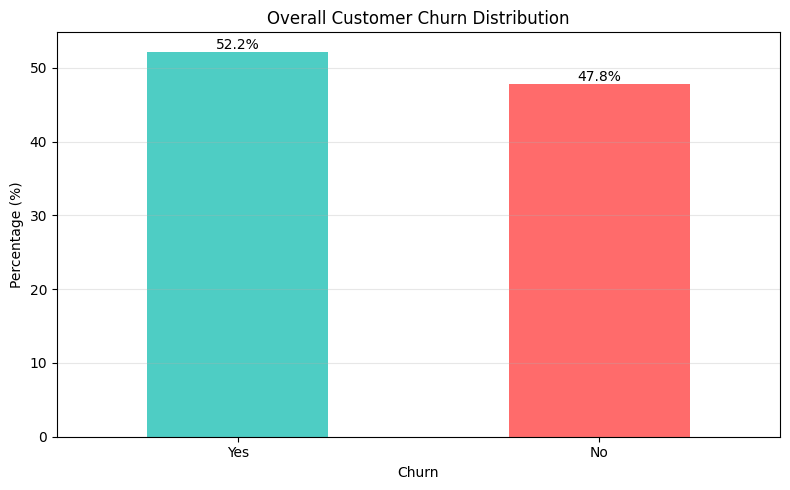

In [64]:
# Overall churn percentage

churn_percentage = df['Churn'].value_counts(normalize=True) * 100

ax = churn_percentage.plot(
    kind='bar',
    figsize=(8, 5),
    color=['#4ECDC4', '#FF6B6B']
)

plt.title('Overall Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

In [65]:
numerical_df = df.select_dtypes(include='number')
correlation = numerical_df.corr()

correlation

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
Age,1.000000,0.006161,0.009242,-0.010183,-0.031130,-0.033460,-0.040291
Annual_Income,0.006161,1.000000,-0.119801,0.011492,0.025274,-0.095589,0.085682
Tenure_Months,0.009242,-0.119801,1.000000,-0.012276,-0.019402,0.002826,0.025597
Monthly_Charges,-0.010183,0.011492,-0.012276,1.000000,0.023744,-0.002669,0.108406
Support_Calls_Last_3M,-0.031130,0.025274,-0.019402,0.023744,1.000000,-0.033688,-0.043770
Data_Usage_GB,-0.033460,-0.095589,0.002826,-0.002669,-0.033688,1.000000,0.070852
Satisfaction_Score,-0.040291,0.085682,0.025597,0.108406,-0.043770,0.070852,1.000000


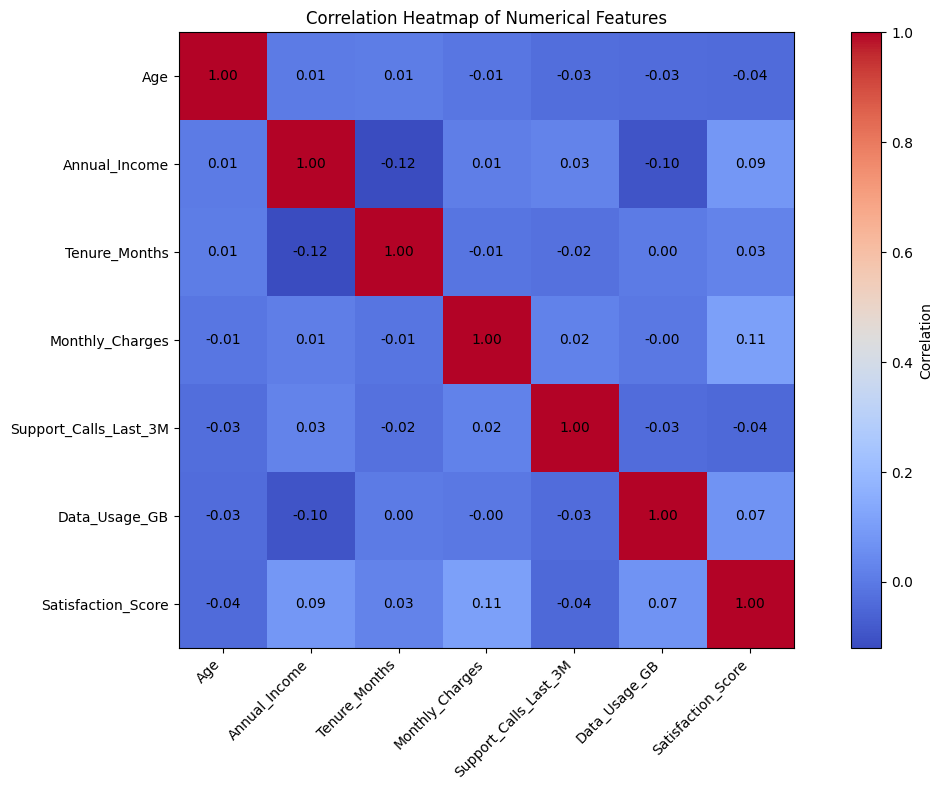

In [66]:
# correlation heatmap
plt.figure(figsize=(12, 8))

plt.imshow(correlation, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation')

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(
            j, i,
            f'{correlation.iloc[i, j]:.2f}',
            ha='center',
            va='center'
        )

plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

## EDA Summary

The EDA was used to understand which customer characteristics appear to be associated with churn. Contract type, satisfaction, tenure, monthly charges, and other customer characteristics were compared between customers who churned and those who stayed.

These observations will help guide feature selection and interpretation of the supervised learning models.

## Feature engineering and preprocessing

#### Separate Features and Target

In [67]:
# Customer_ID is an identifier, so it will not be used as a feature

X = df.drop(columns=['Customer_ID', 'Churn'])
y = df['Churn']

X.head()

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type
0,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,Monthly,Bank Transfer,North,Standard
1,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic
2,55.0,64400.0,49.0,92.85,3.0,21.6,1.0,Monthly,Upi,West,Basic
3,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,Upi,South,Standard
4,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium


#### Convert Target into 0 and 1

In [68]:
# Convert churn labels into numerical values

y = y.map({
    'No': 0,
    'Yes': 1
})

y.head()

0    1
1    1
2    1
3    1
4    1
Name: Churn, dtype: int64

#### Identify Numerical and Categorical Features

In [69]:
# Identify numerical columns
numerical_features = X.select_dtypes(include='number').columns.tolist()

# Identify categorical columns
categorical_features = X.select_dtypes(include='object').columns.tolist()

numerical_features

['Age',
 'Annual_Income',
 'Tenure_Months',
 'Monthly_Charges',
 'Support_Calls_Last_3M',
 'Data_Usage_GB',
 'Satisfaction_Score']

In [70]:
categorical_features

['Contract_Type', 'Payment_Method', 'Region', 'Plan_Type']

#### Train-Test Split

In [71]:
from sklearn.model_selection import train_test_split

# Split data before preprocessing to prevent data leakage

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((144, 11), (36, 11))

#### Create Preprocessing Pipeline

In [72]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical preprocessing
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer([
    ('numerical', numerical_pipeline, numerical_features),
    ('categorical', categorical_pipeline, categorical_features)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_

#### Apply Preprocessing

In [73]:
# Fit preprocessing only on training data
# Then transform both training and testing data

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

X_train_processed.shape, X_test_processed.shape

((144, 23), (36, 23))

#### Check Processed Data

In [74]:
# Check the processed training data

X_train_processed

array([[-0.47048565, -0.08339163, -1.64114613, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.12511816, -0.06122072,  0.56706918, ...,  0.        ,
         1.        ,  0.        ],
       [-0.02378279, -0.10544139, -1.13509679, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [ 0.19956864, -0.08121089,  1.39514992, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.94407339, -0.08957041, -0.07699362, ...,  1.        ,
         0.        ,  0.        ],
       [-0.09823327, -0.10980288, -0.30701605, ...,  0.        ,
         0.        ,  1.        ]], shape=(144, 23))

## Supervised learning models

### Logistic Regression

In [75]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)
logistic_model.fit(X_train_processed,y_train)
logistic_predictions = logistic_model.predict(X_test_processed)

logistic_predictions

array([0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0])

In [76]:
# Calculate evaluation metrics

accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

precision = precision_score(
    y_test,
    logistic_predictions
)

recall = recall_score(
    y_test,
    logistic_predictions
)

f1 = f1_score(
    y_test,
    logistic_predictions
)

# Display results

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.6111111111111112
Accuracy (%): 61.111111111111114
Precision: 0.6470588235294118
Recall: 0.5789473684210527
F1 Score: 0.6111111111111112


In [77]:
# Calculate confusion matrix

cm = confusion_matrix(
    y_test,
    logistic_predictions
)

cm

array([[11,  6],
       [ 8, 11]])

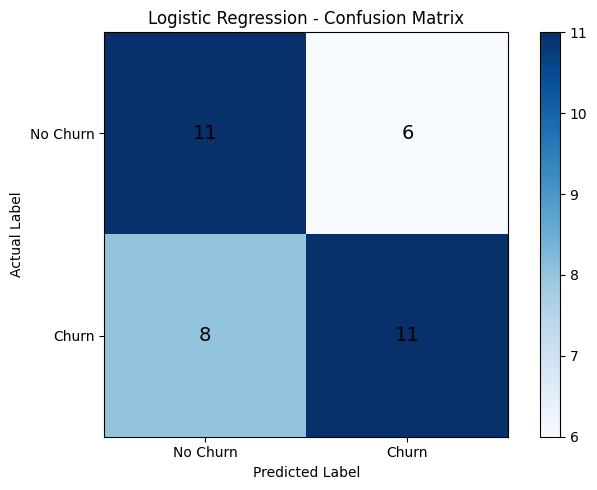

In [78]:
# Plot confusion matrix

plt.figure(figsize=(7, 5))

plt.imshow(
    cm,
    cmap='Blues'
)

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.xticks(
    [0, 1],
    ['No Churn', 'Churn']
)

plt.yticks(
    [0, 1],
    ['No Churn', 'Churn']
)

# Display values inside the matrix

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center',
            fontsize=14
        )

plt.colorbar()

plt.tight_layout()
plt.show()

In [79]:
# Generate classification report

classification_report_result = classification_report(
    y_test,
    logistic_predictions,
    target_names=['No Churn', 'Churn']
)

print(classification_report_result)

              precision    recall  f1-score   support

    No Churn       0.58      0.65      0.61        17
       Churn       0.65      0.58      0.61        19

    accuracy                           0.61        36
   macro avg       0.61      0.61      0.61        36
weighted avg       0.61      0.61      0.61        36



In [80]:
# Get probability predictions

logistic_probabilities = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

roc_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.6408668730650154


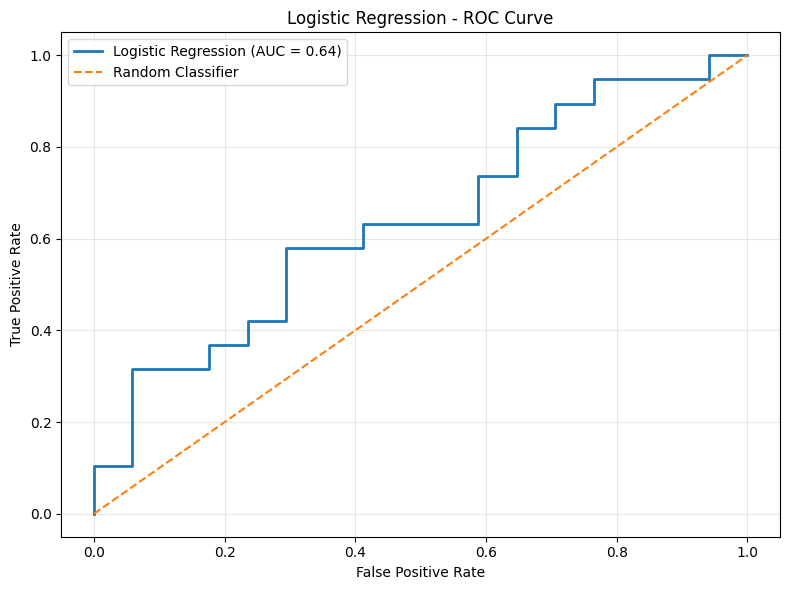

In [81]:
# Calculate ROC curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    logistic_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'Logistic Regression (AUC = {roc_auc:.2f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('Logistic Regression - ROC Curve')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [82]:
# Display all main Logistic Regression results

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC Score:", roc_auc)

Logistic Regression Performance
--------------------------------
Accuracy: 0.6111111111111112
Accuracy (%): 61.111111111111114
Precision: 0.6470588235294118
Recall: 0.5789473684210527
F1 Score: 0.6111111111111112
ROC-AUC Score: 0.6408668730650154


### KNN

In [83]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_processed,y_train)
knn_predictions = knn_model.predict(X_test_processed)

knn_predictions

array([1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0])

In [84]:
# Calculate evaluation metrics

accuracy = accuracy_score(
    y_test,
    knn_predictions
)

precision = precision_score(
    y_test,
    knn_predictions
)

recall = recall_score(
    y_test,
    knn_predictions
)

f1 = f1_score(
    y_test,
    knn_predictions
)


print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.5833333333333334
Accuracy (%): 58.333333333333336
Precision: 0.5833333333333334
Recall: 0.7368421052631579
F1 Score: 0.6511627906976745


In [85]:
# Calculate confusion matrix

cm = confusion_matrix(
    y_test,
    knn_predictions
)

cm

array([[ 7, 10],
       [ 5, 14]])

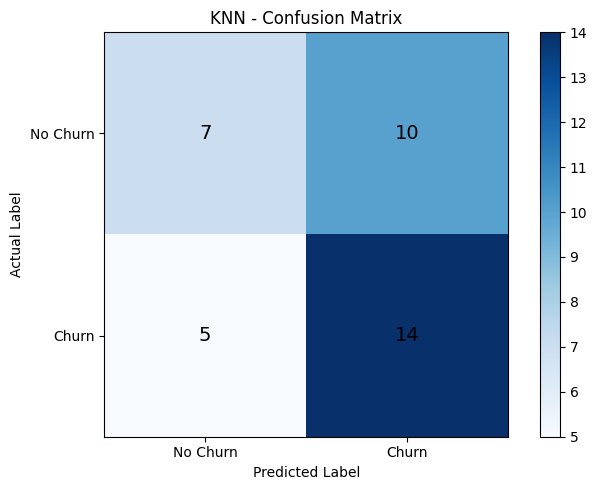

In [86]:
plt.figure(figsize=(7, 5))

plt.imshow(
    cm,
    cmap='Blues'
)

plt.title('KNN - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.xticks(
    [0, 1],
    ['No Churn', 'Churn']
)

plt.yticks(
    [0, 1],
    ['No Churn', 'Churn']
)

# Display values inside the matrix

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center',
            fontsize=14
        )

plt.colorbar()

plt.tight_layout()
plt.show()

In [87]:
# Generate classification report

classification_report_result = classification_report(
    y_test,
    knn_predictions,
    target_names=['No Churn', 'Churn']
)

print(classification_report_result)

              precision    recall  f1-score   support

    No Churn       0.58      0.41      0.48        17
       Churn       0.58      0.74      0.65        19

    accuracy                           0.58        36
   macro avg       0.58      0.57      0.57        36
weighted avg       0.58      0.58      0.57        36



In [88]:
# Get probability predictions

knn_probabilities = knn_model.predict_proba(
    X_test_processed
)[:, 1]

roc_auc = roc_auc_score(
    y_test,
    knn_probabilities
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.6563467492260062


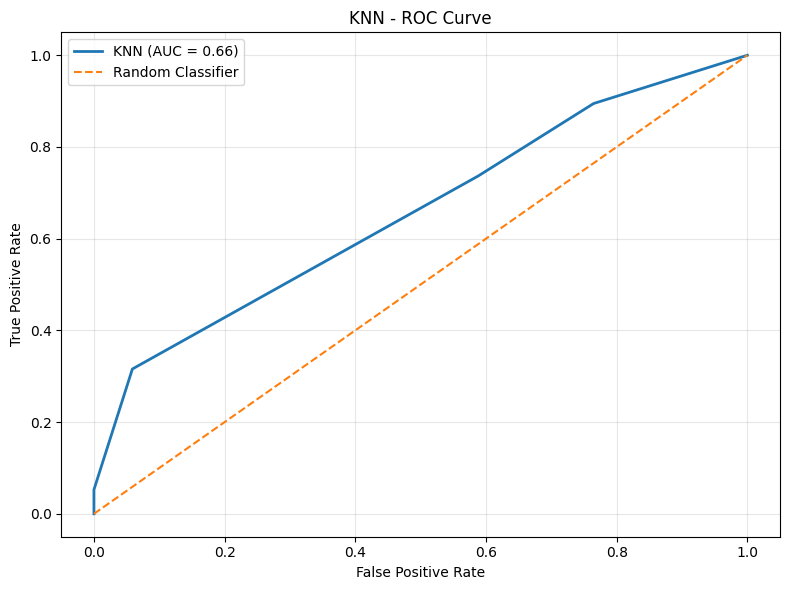

In [89]:
# Calculate ROC curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    knn_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'KNN (AUC = {roc_auc:.2f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('KNN - ROC Curve')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [90]:
# Display all main KNN results

print("KNN Performance")
print("----------------")
print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC Score:", roc_auc)

KNN Performance
----------------
Accuracy: 0.5833333333333334
Accuracy (%): 58.333333333333336
Precision: 0.5833333333333334
Recall: 0.7368421052631579
F1 Score: 0.6511627906976745
ROC-AUC Score: 0.6563467492260062


## Decision Tree

In [91]:
# Create Decision Tree model

decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train_processed,y_train)
decision_tree_predictions = decision_tree_model.predict(X_test_processed)

decision_tree_predictions



array([0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1])

In [92]:
# Calculate evaluation metrics

accuracy = accuracy_score(
    y_test,
    decision_tree_predictions
)

precision = precision_score(
    y_test,
    decision_tree_predictions
)

recall = recall_score(
    y_test,
    decision_tree_predictions
)

f1 = f1_score(
    y_test,
    decision_tree_predictions
)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.4722222222222222
Accuracy (%): 47.22222222222222
Precision: 0.5
Recall: 0.3684210526315789
F1 Score: 0.42424242424242425


In [93]:
# Calculate confusion matrix

cm = confusion_matrix(
    y_test,
    decision_tree_predictions
)

cm

array([[10,  7],
       [12,  7]])

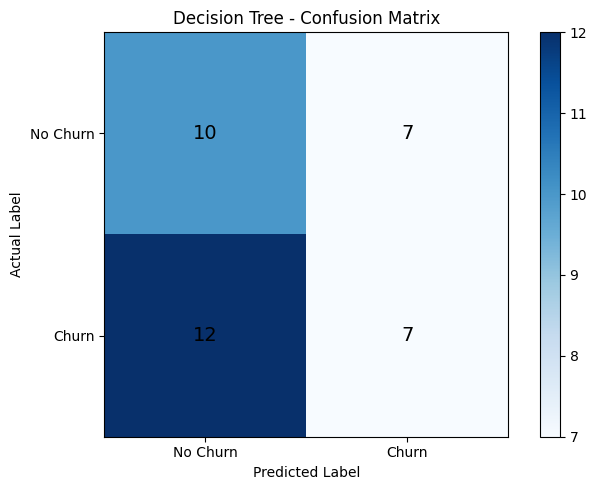

In [94]:
# Plot confusion matrix

plt.figure(figsize=(7, 5))

plt.imshow(
    cm,
    cmap='Blues'
)

plt.title('Decision Tree - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.xticks(
    [0, 1],
    ['No Churn', 'Churn']
)

plt.yticks(
    [0, 1],
    ['No Churn', 'Churn']
)


for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center',
            fontsize=14
        )

plt.colorbar()

plt.tight_layout()
plt.show()

In [95]:
# Generate classification report

classification_report_result = classification_report(
    y_test,
    decision_tree_predictions,
    target_names=['No Churn', 'Churn']
)

print(classification_report_result)

              precision    recall  f1-score   support

    No Churn       0.45      0.59      0.51        17
       Churn       0.50      0.37      0.42        19

    accuracy                           0.47        36
   macro avg       0.48      0.48      0.47        36
weighted avg       0.48      0.47      0.47        36



In [96]:
# Get probability predictions

decision_tree_probabilities = decision_tree_model.predict_proba(
    X_test_processed
)[:, 1]

roc_auc = roc_auc_score(
    y_test,
    decision_tree_probabilities
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.47832817337461303


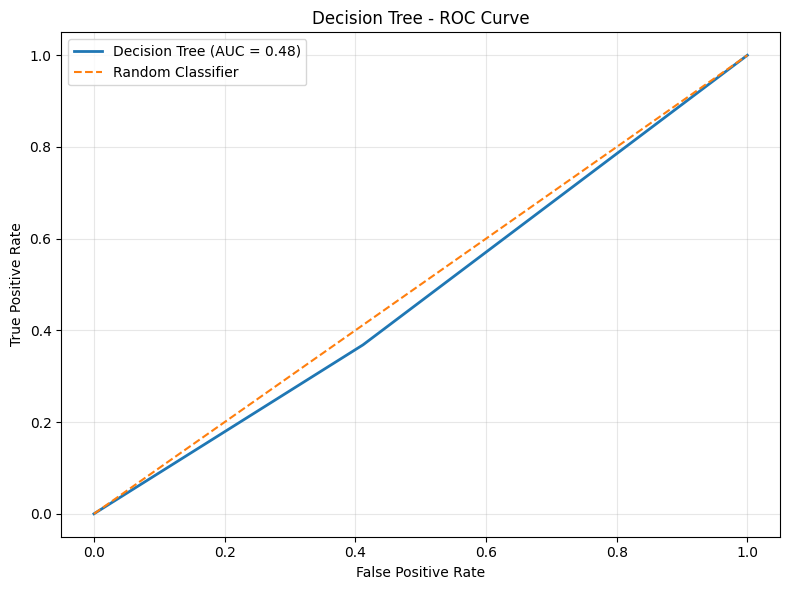

In [97]:
# Calculate ROC curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    decision_tree_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'Decision Tree (AUC = {roc_auc:.2f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('Decision Tree - ROC Curve')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [98]:
# Display all main Decision Tree results

print("Decision Tree Performance")
print("-------------------------")
print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC Score:", roc_auc)

Decision Tree Performance
-------------------------
Accuracy: 0.4722222222222222
Accuracy (%): 47.22222222222222
Precision: 0.5
Recall: 0.3684210526315789
F1 Score: 0.42424242424242425
ROC-AUC Score: 0.47832817337461303


## Random Forest

In [99]:
# Create Random Forest model

random_forest_model = RandomForestClassifier(n_estimators=100,random_state=42)
random_forest_model.fit(X_train_processed,y_train)
random_forest_predictions = random_forest_model.predict(X_test_processed)

random_forest_predictions


array([0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0])

In [100]:
# Calculate evaluation metrics

accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

precision = precision_score(
    y_test,
    random_forest_predictions
)

recall = recall_score(
    y_test,
    random_forest_predictions
)

f1 = f1_score(
    y_test,
    random_forest_predictions
)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.5277777777777778
Accuracy (%): 52.77777777777778
Precision: 0.5833333333333334
Recall: 0.3684210526315789
F1 Score: 0.45161290322580644


In [101]:
# Calculate confusion matrix

cm = confusion_matrix(
    y_test,
    random_forest_predictions
)

cm

array([[12,  5],
       [12,  7]])

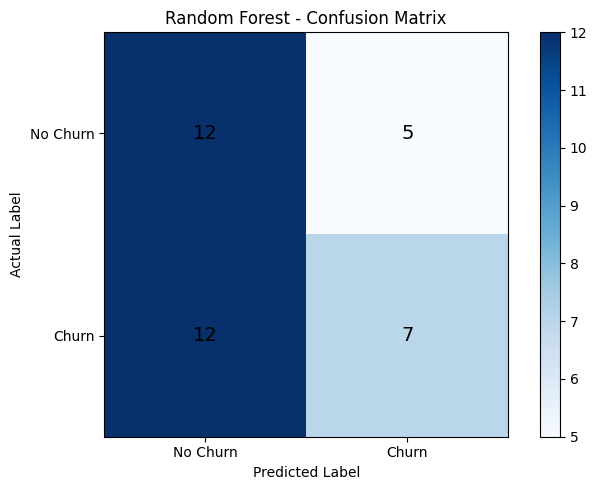

In [102]:
# Plot confusion matrix

plt.figure(figsize=(7, 5))

plt.imshow(
    cm,
    cmap='Blues'
)

plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.xticks(
    [0, 1],
    ['No Churn', 'Churn']
)

plt.yticks(
    [0, 1],
    ['No Churn', 'Churn']
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center',
            fontsize=14
        )

plt.colorbar()

plt.tight_layout()
plt.show()

In [103]:
# Generate classification report

classification_report_result = classification_report(
    y_test,
    random_forest_predictions,
    target_names=['No Churn', 'Churn']
)

print(classification_report_result)

              precision    recall  f1-score   support

    No Churn       0.50      0.71      0.59        17
       Churn       0.58      0.37      0.45        19

    accuracy                           0.53        36
   macro avg       0.54      0.54      0.52        36
weighted avg       0.54      0.53      0.51        36



In [104]:
# Get probability predictions

random_forest_probabilities = random_forest_model.predict_proba(
    X_test_processed
)[:, 1]


roc_auc = roc_auc_score(
    y_test,
    random_forest_probabilities
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.6904024767801857


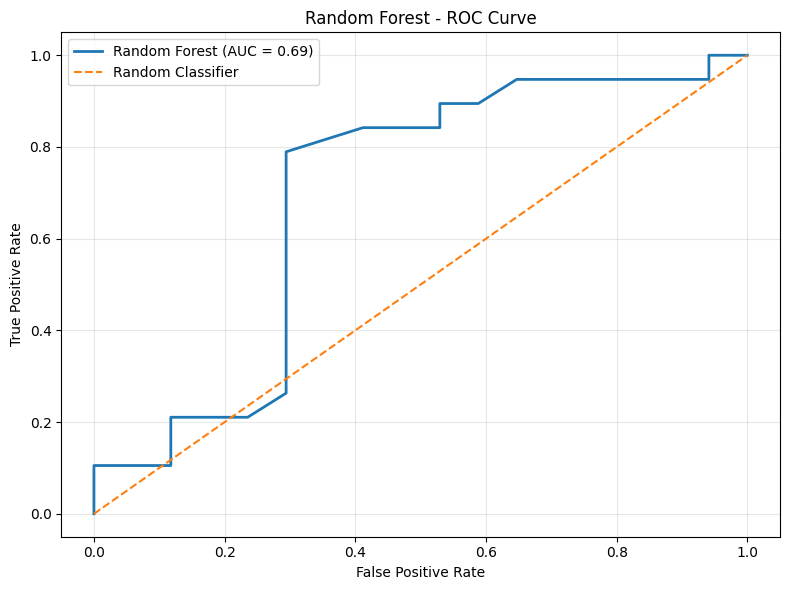

In [105]:
# Calculate ROC curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    random_forest_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'Random Forest (AUC = {roc_auc:.2f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('Random Forest - ROC Curve')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [106]:
# Display all main Random Forest results

print("Random Forest Performance")
print("------------------------")
print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC Score:", roc_auc)

Random Forest Performance
------------------------
Accuracy: 0.5277777777777778
Accuracy (%): 52.77777777777778
Precision: 0.5833333333333334
Recall: 0.3684210526315789
F1 Score: 0.45161290322580644
ROC-AUC Score: 0.6904024767801857


## AdaBoost

In [107]:
# Import AdaBoost classifier

from sklearn.ensemble import AdaBoostClassifier
adaboost_model = AdaBoostClassifier(n_estimators=100,random_state=42)
adaboost_model.fit(X_train_processed,y_train)
adaboost_predictions = adaboost_model.predict(X_test_processed)

adaboost_predictions



array([0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0])

In [108]:
# Calculate evaluation metrics

accuracy = accuracy_score(
    y_test,
    adaboost_predictions
)

precision = precision_score(
    y_test,
    adaboost_predictions
)

recall = recall_score(
    y_test,
    adaboost_predictions
)

f1 = f1_score(
    y_test,
    adaboost_predictions
)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.6111111111111112
Accuracy (%): 61.111111111111114
Precision: 0.6923076923076923
Recall: 0.47368421052631576
F1 Score: 0.5625


In [109]:
# Calculate confusion matrix

cm = confusion_matrix(
    y_test,
    adaboost_predictions
)

cm

array([[13,  4],
       [10,  9]])

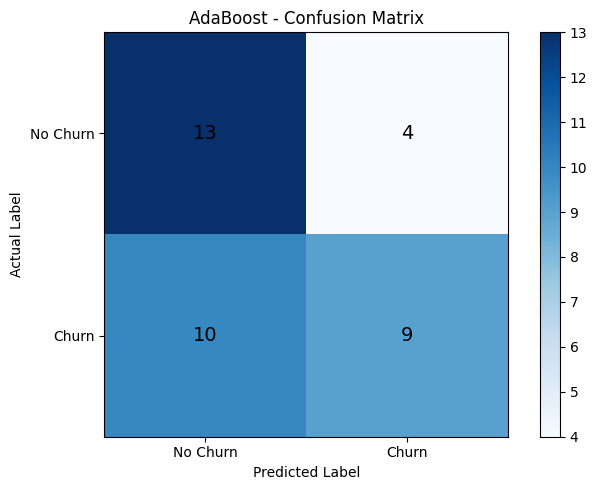

In [110]:
# Plot confusion matrix

plt.figure(figsize=(7, 5))

plt.imshow(
    cm,
    cmap='Blues'
)

plt.title('AdaBoost - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.xticks(
    [0, 1],
    ['No Churn', 'Churn']
)

plt.yticks(
    [0, 1],
    ['No Churn', 'Churn']
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center',
            fontsize=14
        )

plt.colorbar()

plt.tight_layout()
plt.show()

In [111]:
# Generate classification report

classification_report_result = classification_report(
    y_test,
    adaboost_predictions,
    target_names=['No Churn', 'Churn']
)

print(classification_report_result)

              precision    recall  f1-score   support

    No Churn       0.57      0.76      0.65        17
       Churn       0.69      0.47      0.56        19

    accuracy                           0.61        36
   macro avg       0.63      0.62      0.61        36
weighted avg       0.63      0.61      0.60        36



In [112]:
# Get probability predictions

adaboost_probabilities = adaboost_model.predict_proba(
    X_test_processed
)[:, 1]

roc_auc = roc_auc_score(
    y_test,
    adaboost_probabilities
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.6006191950464396


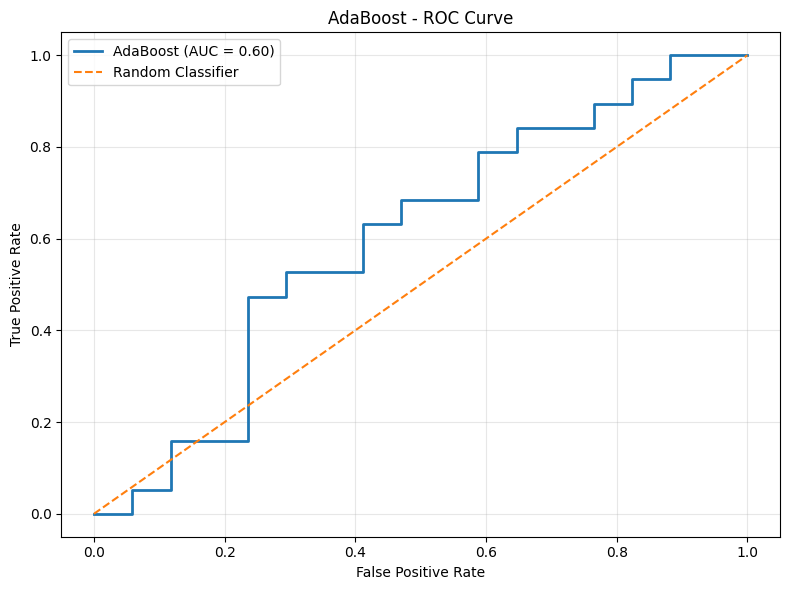

In [113]:
# Calculate ROC curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    adaboost_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'AdaBoost (AUC = {roc_auc:.2f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('AdaBoost - ROC Curve')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [114]:
# Display all main AdaBoost results

print("AdaBoost Performance")
print("--------------------")
print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC Score:", roc_auc)

AdaBoost Performance
--------------------
Accuracy: 0.6111111111111112
Accuracy (%): 61.111111111111114
Precision: 0.6923076923076923
Recall: 0.47368421052631576
F1 Score: 0.5625
ROC-AUC Score: 0.6006191950464396


## Gradient Boosting

In [115]:
# Import Gradient Boosting Classifier

from sklearn.ensemble import GradientBoostingClassifier
gradient_boost_model = GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gradient_boost_model.fit(X_train_processed,y_train)
gradient_boost_predictions = gradient_boost_model.predict(X_test_processed)

gradient_boost_predictions


array([0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0])

In [116]:
# Calculate evaluation metrics

accuracy = accuracy_score(
    y_test,
    gradient_boost_predictions
)

precision = precision_score(
    y_test,
    gradient_boost_predictions
)

recall = recall_score(
    y_test,
    gradient_boost_predictions
)

f1 = f1_score(
    y_test,
    gradient_boost_predictions
)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.5555555555555556
Accuracy (%): 55.55555555555556
Precision: 0.6
Recall: 0.47368421052631576
F1 Score: 0.5294117647058824


In [117]:
# Create confusion matrix

cm = confusion_matrix(
    y_test,
    gradient_boost_predictions
)

cm

array([[11,  6],
       [10,  9]])

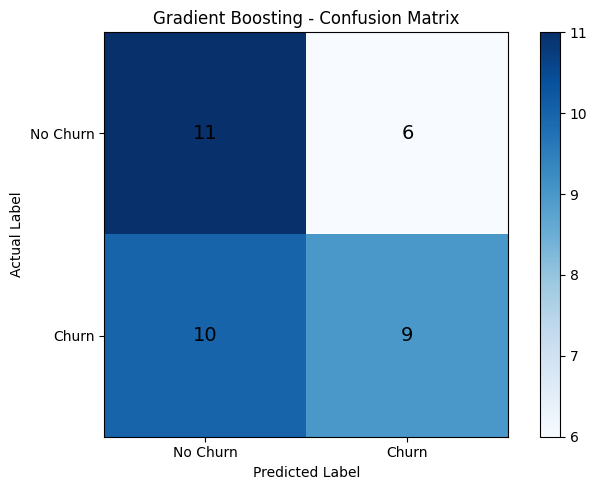

In [118]:
# Plot confusion matrix

plt.figure(figsize=(7, 5))

plt.imshow(
    cm,
    cmap='Blues'
)

plt.title('Gradient Boosting - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.xticks(
    [0, 1],
    ['No Churn', 'Churn']
)

plt.yticks(
    [0, 1],
    ['No Churn', 'Churn']
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center',
            fontsize=14
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [119]:
# Generate classification report

classification_report_result = classification_report(
    y_test,
    gradient_boost_predictions,
    target_names=['No Churn', 'Churn']
)

print(classification_report_result)

              precision    recall  f1-score   support

    No Churn       0.52      0.65      0.58        17
       Churn       0.60      0.47      0.53        19

    accuracy                           0.56        36
   macro avg       0.56      0.56      0.55        36
weighted avg       0.56      0.56      0.55        36



In [120]:
# Get probability predictions

gradient_boost_probabilities = gradient_boost_model.predict_proba(
    X_test_processed
)[:, 1]

# Calculate ROC-AUC

roc_auc = roc_auc_score(
    y_test,
    gradient_boost_probabilities
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.6006191950464396


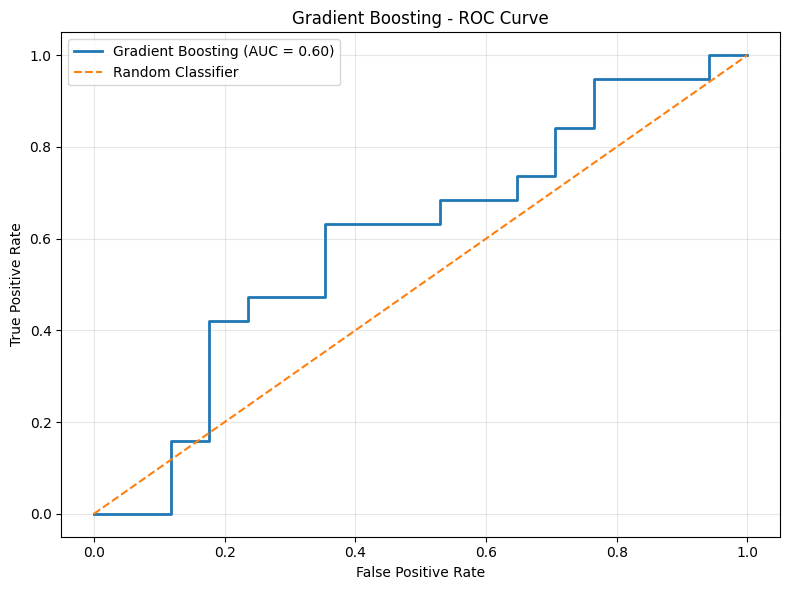

In [121]:
# Calculate ROC curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    gradient_boost_probabilities
)

# Plot ROC curve

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'Gradient Boosting (AUC = {roc_auc:.2f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Gradient Boosting - ROC Curve')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [122]:
# Final Gradient Boosting performance

print("Gradient Boosting Performance")
print("-----------------------------")
print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC Score:", roc_auc)

Gradient Boosting Performance
-----------------------------
Accuracy: 0.5555555555555556
Accuracy (%): 55.55555555555556
Precision: 0.6
Recall: 0.47368421052631576
F1 Score: 0.5294117647058824
ROC-AUC Score: 0.6006191950464396


## Model Evaluation

In [123]:
# Model Evaluation Table

models = {
    'Logistic Regression': logistic_predictions,
    'KNN': knn_predictions,
    'Decision Tree': decision_tree_predictions,
    'Random Forest': random_forest_predictions,
    'AdaBoost': adaboost_predictions,
    'Gradient Boosting': gradient_boost_predictions
}

results = []

for model_name, predictions in models.items():

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, zero_division=0)
    recall = recall_score(y_test, predictions, zero_division=0)
    f1 = f1_score(y_test, predictions, zero_division=0)

    results.append({
        'Model': model_name,
        'Accuracy': round(accuracy, 4),
        'Accuracy (%)': round(accuracy * 100, 2),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4)
    })

evaluation_table = pd.DataFrame(results)

evaluation_table

,Model,Accuracy,Accuracy (%),Precision,Recall,F1-Score
0,Logistic Regression,0.6111,61.11,0.6471,0.5789,0.6111
1,KNN,0.5833,58.33,0.5833,0.7368,0.6512
2,Decision Tree,0.4722,47.22,0.5000,0.3684,0.4242
3,Random Forest,0.5278,52.78,0.5833,0.3684,0.4516
4,AdaBoost,0.6111,61.11,0.6923,0.4737,0.5625
5,Gradient Boosting,0.5556,55.56,0.6000,0.4737,0.5294


## Cross-Validation

In [124]:
# Step 8 - Cross-Validation and Model Stability

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Create pipelines so preprocessing is performed separately inside each CV fold
cv_models = {
    'Logistic Regression': LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    'KNN': KNeighborsClassifier(
        n_neighbors=5
    ),

    'Decision Tree': DecisionTreeClassifier(
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    'AdaBoost': AdaBoostClassifier(
        n_estimators=100,
        random_state=42
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
}

results = []

for model_name, model in cv_models.items():

    # Create complete pipeline
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    # Apply 5-fold cross-validation on training data
    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    # Calculate CV mean and standard deviation
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()

    # Get test accuracy from already trained models
    if model_name == 'Logistic Regression':
        predictions = logistic_predictions
    elif model_name == 'KNN':
        predictions = knn_predictions
    elif model_name == 'Decision Tree':
        predictions = decision_tree_predictions
    elif model_name == 'Random Forest':
        predictions = random_forest_predictions
    elif model_name == 'AdaBoost':
        predictions = adaboost_predictions
    elif model_name == 'Gradient Boosting':
        predictions = gradient_boost_predictions

    test_accuracy = accuracy_score(
        y_test,
        predictions
    )

    # Difference between CV and test performance
    difference = cv_mean - test_accuracy

    # Simple interpretation
    if cv_mean >= 0.70 and test_accuracy < cv_mean - 0.10:
        interpretation = "Possible Overfitting"
    elif cv_mean < 0.60 and test_accuracy < 0.60:
        interpretation = "Possible Underfitting"
    else:
        interpretation = "Reasonably Stable"

    results.append({
        'Model': model_name,
        'CV Mean Accuracy': round(cv_mean, 4),
        'CV Std': round(cv_std, 4),
        'Test Accuracy': round(test_accuracy, 4),
        'Difference': round(difference, 4),
        'Interpretation': interpretation
    })

# Create final comparison table
cross_validation_table = pd.DataFrame(results)

cross_validation_table

,Model,CV Mean Accuracy,CV Std,Test Accuracy,Difference,Interpretation
0,Logistic Regression,0.5966,0.0923,0.6111,-0.0146,Reasonably Stable
1,KNN,0.5414,0.1193,0.5833,-0.0420,Possible Underfitting
2,Decision Tree,0.5409,0.0903,0.4722,0.0687,Possible Underfitting
3,Random Forest,0.5135,0.0641,0.5278,-0.0142,Possible Underfitting
4,AdaBoost,0.5766,0.0377,0.6111,-0.0345,Reasonably Stable
5,Gradient Boosting,0.4796,0.0760,0.5556,-0.0760,Possible Underfitting


## Model Comparision

In [125]:
# Step 9 - Model Comparison Table

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Store predictions from all models
model_predictions = {
    'Logistic Regression': logistic_predictions,
    'KNN': knn_predictions,
    'Decision Tree': decision_tree_predictions,
    'Random Forest': random_forest_predictions,
    'AdaBoost': adaboost_predictions,
    'Gradient Boosting': gradient_boost_predictions
}

comparison_results = []

for model_name, predictions in model_predictions.items():

    # Calculate test performance
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )
    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    # Get CV Score from the cross-validation table
    cv_score = cross_validation_table.loc[
        cross_validation_table['Model'] == model_name,
        'CV Mean Accuracy'
    ].values[0]

    # Add results
    comparison_results.append({
        'Model': model_name,
        'Accuracy': round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1': round(f1, 4),
        'CV Score': round(cv_score, 4)
    })

# Create comparison table
model_comparison = pd.DataFrame(comparison_results)

# Display the table
model_comparison

,Model,Accuracy,Precision,Recall,F1,CV Score
0,Logistic Regression,0.6111,0.6471,0.5789,0.6111,0.5966
1,KNN,0.5833,0.5833,0.7368,0.6512,0.5414
2,Decision Tree,0.4722,0.5000,0.3684,0.4242,0.5409
3,Random Forest,0.5278,0.5833,0.3684,0.4516,0.5135
4,AdaBoost,0.6111,0.6923,0.4737,0.5625,0.5766
5,Gradient Boosting,0.5556,0.6000,0.4737,0.5294,0.4796


## Model Trade-offs

The models were compared using Accuracy, Precision, Recall, F1-score, and Cross-Validation Score.

- **Logistic Regression:** Simple and easy to interpret, but may not capture complex relationships in the data.
- **KNN:** Simple and useful for pattern-based classification, but its performance can be affected by the choice of `k` and feature scaling.
- **Decision Tree:** Easy to understand and can capture non-linear patterns, but it can overfit the training data.
- **Random Forest:** More robust than a single decision tree and generally provides better stability, but it is more complex and less interpretable.
- **AdaBoost:** Combines multiple weak learners to improve prediction, but can be sensitive to noisy data and outliers.
- **Gradient Boosting:** Can capture complex patterns and improve prediction performance, but it may require more tuning and can overfit if not controlled.

Model selection should not be based only on the highest training score. The **test performance, cross-validation score, Precision, Recall, F1-score, and model stability** should also be considered. A model with a high training score but much lower test or cross-validation performance may indicate overfitting.

For this customer churn problem, **Recall and F1-score are particularly important** because missing customers who are likely to churn can reduce the effectiveness of retention efforts. Therefore, the final model should be selected by considering the overall evaluation results rather than a single metric.

## Final Model

In [126]:
# Step 10 - Final Model Selection

# Create a combined score using F1-score and CV Score
# Both metrics are important for customer churn prediction

model_comparison['Combined Score'] = (
    model_comparison['F1'] * 0.6
    + model_comparison['CV Score'] * 0.4
)

best_model_name = model_comparison.loc[
    model_comparison['Combined Score'].idxmax(),
    'Model'
]

model_comparison

,Model,Accuracy,Precision,Recall,F1,CV Score,Combined Score
0,Logistic Regression,0.6111,0.6471,0.5789,0.6111,0.5966,0.60530
1,KNN,0.5833,0.5833,0.7368,0.6512,0.5414,0.60728
2,Decision Tree,0.4722,0.5000,0.3684,0.4242,0.5409,0.47088
3,Random Forest,0.5278,0.5833,0.3684,0.4516,0.5135,0.47636
4,AdaBoost,0.6111,0.6923,0.4737,0.5625,0.5766,0.56814
5,Gradient Boosting,0.5556,0.6000,0.4737,0.5294,0.4796,0.50948


## Selected Model

In [127]:
# Display the selected final model
print("=" * 65)
print("FINAL SELECTED MODEL")
print("=" * 65)
print("Model:", best_model_name)

print("\nReason for Selection:")
print("The model was selected based on F1-score and cross-validation")
print("performance rather than training accuracy alone.")
print("F1-score considers both Precision and Recall, while")
print("cross-validation helps evaluate model stability.")

FINAL SELECTED MODEL
Model: KNN

Reason for Selection:
The model was selected based on F1-score and cross-validation
performance rather than training accuracy alone.
F1-score considers both Precision and Recall, while
cross-validation helps evaluate model stability.


In [128]:
# Display performance of the selected final model

final_model_results = model_comparison[
    model_comparison['Model'] == best_model_name
]

final_model_results

,Model,Accuracy,Precision,Recall,F1,CV Score,Combined Score
1,KNN,0.5833,0.5833,0.7368,0.6512,0.5414,0.60728


## Final model Confusion Matrix

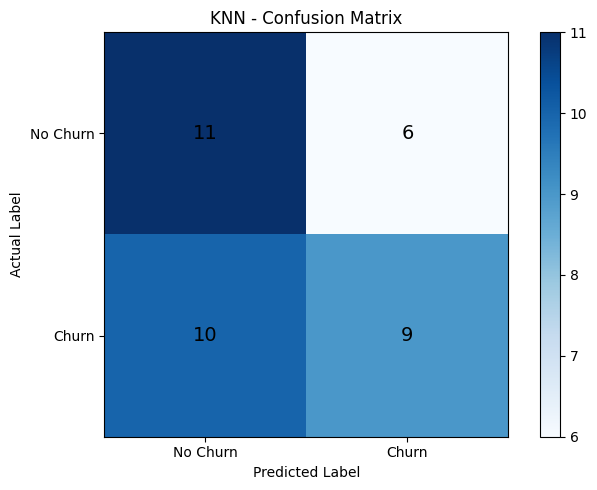

In [129]:
plt.figure(figsize=(7, 5))

plt.imshow(
    cm,
    cmap='Blues'
)

plt.title('KNN - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.xticks(
    [0, 1],
    ['No Churn', 'Churn']
)

plt.yticks(
    [0, 1],
    ['No Churn', 'Churn']
)

# Display values inside the matrix

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center',
            fontsize=14
        )

plt.colorbar()

plt.tight_layout()
plt.show()

## Final Model Explanation

- **Why selected:** The model was selected based on its F1-score, cross-validation performance, and test results rather than training accuracy alone.

- **Important features:** Features such as **Contract Type, Satisfaction Score, Tenure, Monthly Charges, and Support Calls** appear useful for predicting customer churn.

- **Model errors:** False Negatives are customers who are likely to churn but are predicted as non-churn. False Positives are customers predicted to churn who actually stay.

- **Business use:** The business can use churn predictions to identify customers at higher risk of leaving and provide targeted retention offers, support, or follow-up.

## Business Recommendations

1. **Target high-risk customers:** Use the churn predictions to identify customers who are more likely to leave and prioritize them for retention campaigns.

2. **Improve customer satisfaction:** Customers with lower satisfaction scores can be given faster support, follow-ups, and personalized assistance.

3. **Monitor support issues:** Customers with frequent support calls should be reviewed and contacted to understand and resolve their problems.

4. **Focus on contract and pricing:** Review customers with contract types or monthly charges associated with higher churn and provide suitable plans or retention offers.

5. **Use regular churn monitoring:** Run the model regularly so the retention team can identify new high-risk customers and take action before they leave.

## Conclusion

The final model was selected based on its **F1-score, cross-validation performance, and test performance**, rather than training accuracy alone. It can help the retention team identify customers who are more likely to churn and take preventive actions.

### Limitations

- The dataset is relatively small and contains messy data.
- Model performance may change when applied to new customer data.
- Some important customer information may not be available in the dataset.
- False positives and false negatives can affect business decisions.
- Additional historical customer and service data could improve the model.